### Задание

Попробуйте поработать с датасетом юридических текстов. В датасете всего две важных колонки признаков: заголовок дела и его текст, а целевая переменная - case_outcome (мультиклассовая классификация). 

В базовом варианте можно оставить только текст дела, если хотите поинтереснее - можно попробовать распарсить case_title, добыв оттуда дополнительные признаки. 

https://www.kaggle.com/datasets/amohankumar/legal-text-classification-dataset

In [39]:
import kagglehub
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [24]:
path = kagglehub.dataset_download("amohankumar/legal-text-classification-dataset")
filepath = path + "/legal_text_classification.csv"
df = pd.read_csv(filepath)

In [ ]:
df.head()

,case_id,case_outcome,case_title,case_text
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...,Ordinarily that discretion will be exercised s...
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...,The general principles governing the exercise ...
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...,Ordinarily that discretion will be exercised s...
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...,The general principles governing the exercise ...
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holding...,The preceding general principles inform the ex...


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24985 entries, 0 to 24984
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   case_id       24985 non-null  object
 1   case_outcome  24985 non-null  object
 2   case_title    24985 non-null  object
 3   case_text     24809 non-null  object
dtypes: object(4)
memory usage: 780.9+ KB


In [27]:
df["case_outcome"].unique()

array(['cited', 'applied', 'followed', 'referred to', 'related',
       'considered', 'discussed', 'distinguished', 'affirmed', 'approved'],
      dtype=object)

In [ ]:
df["case_outcome"].value_counts()

case_outcome
cited            12219
referred to       4384
applied           2448
followed          2256
considered        1712
discussed         1024
distinguished      608
related            113
affirmed           113
approved           108
Name: count, dtype: int64

In [ ]:
# минус пропуски, подвыборка для ускорения

df_clean = df.dropna(subset=["case_text", "case_outcome", "case_title"]).sample(5000, random_state=42)

# case_title + case_text и чистим

df_clean["full_text"] = df_clean["case_title"].fillna("") + " " + df_clean["case_text"].fillna("")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_clean["clean_text"] = df_clean["full_text"].apply(clean_text)


In [30]:
X = df_clean["clean_text"]
y = df_clean["case_outcome"]

In [ ]:
# стратифицированная кросс-валидация

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [32]:
# логистическая регрессия

pipeline_lr = make_pipeline(
    TfidfVectorizer(max_features=10000, ngram_range=(1, 2)),
    LogisticRegression(
        multi_class="multinomial",
        solver="saga",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
)

In [ ]:
# lightgbm

pipeline_lgbm = make_pipeline(
    TfidfVectorizer(max_features=10000, ngram_range=(1, 2)),
    LGBMClassifier(
        class_weight="balanced",
       )
)

In [36]:
results = {}

for name, model in {
    "LogReg": pipeline_lr,
    "LightGBM": pipeline_lgbm
}.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=["f1_macro", "accuracy"], n_jobs=-1)
    results[name + " F1_macro"] = round(np.mean(scores["test_f1_macro"]), 4)
    results[name + " Accuracy"] = round(np.mean(scores["test_accuracy"]), 4)

results

{'LogReg F1_macro': np.float64(0.1598),
 'LogReg Accuracy': np.float64(0.2552),
 'LightGBM F1_macro': np.float64(0.2081),
 'LightGBM Accuracy': np.float64(0.495)}

In [38]:
# обучим модель на всём корпусе для интерпретации

pipeline_lr.fit(X, y)

# достаю обученные шаги

vec = pipeline_lr.named_steps['tfidfvectorizer']
clf = pipeline_lr.named_steps['logisticregression']
feature_names = np.array(vec.get_feature_names_out())

# для каждого класса выводим топ-10 признаков по абсолютному весу

for i, class_name in enumerate(clf.classes_):
    top = np.argsort(clf.coef_[i])[-10:][::-1]
    print(f"\nкласс: {class_name}")
    print("топ-слова:", feature_names[top])


c:\Users\Anastasia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



класс: affirmed
топ-слова: ['claimed' 'fmca' 'claimed that' 'yang' 'claimed to' 'computer' 'he'
 'china' 'ms' 'appellant']

класс: applied
топ-слова: ['hca' 'to' 'clr' 'hca clr' 'must' 'to be' 'at' 'reasonable' 'leave' 'or']

класс: approved
топ-слова: ['rural press' 'rural' 'user' 'acsr' 'press' 'direction' 'freedom'
 'informed' 'flr' 'the attorneygeneral']

класс: cited
топ-слова: ['evidence' 'hca clr' 'hca' 'at' 'alr at' 'or' 'information' 'aust' 'clr'
 'fcafc']

класс: considered
топ-слова: ['mark' 'of' 'that case' 'court' 'as to' 'whether' 'in that' 'be' 'case'
 'court of']

класс: discussed
топ-слова: ['the' 'particulars' 'accountants' 'had' 'land' 'as' 'their' 'trust'
 'they' 'held']

класс: distinguished
топ-слова: ['was' 'railway' 'shares' 'citizenship fcafc' 'of state' 'registrar'
 'different from' 'wlr' 'nominees' 'case']

класс: followed
топ-слова: ['fcafc' 'immigration amp' 'be' 'alr' 'at per' 'alr at' 'the court'
 'employee' 'at' 'amp citizenship']

класс: referred to
то

c:\Users\Anastasia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


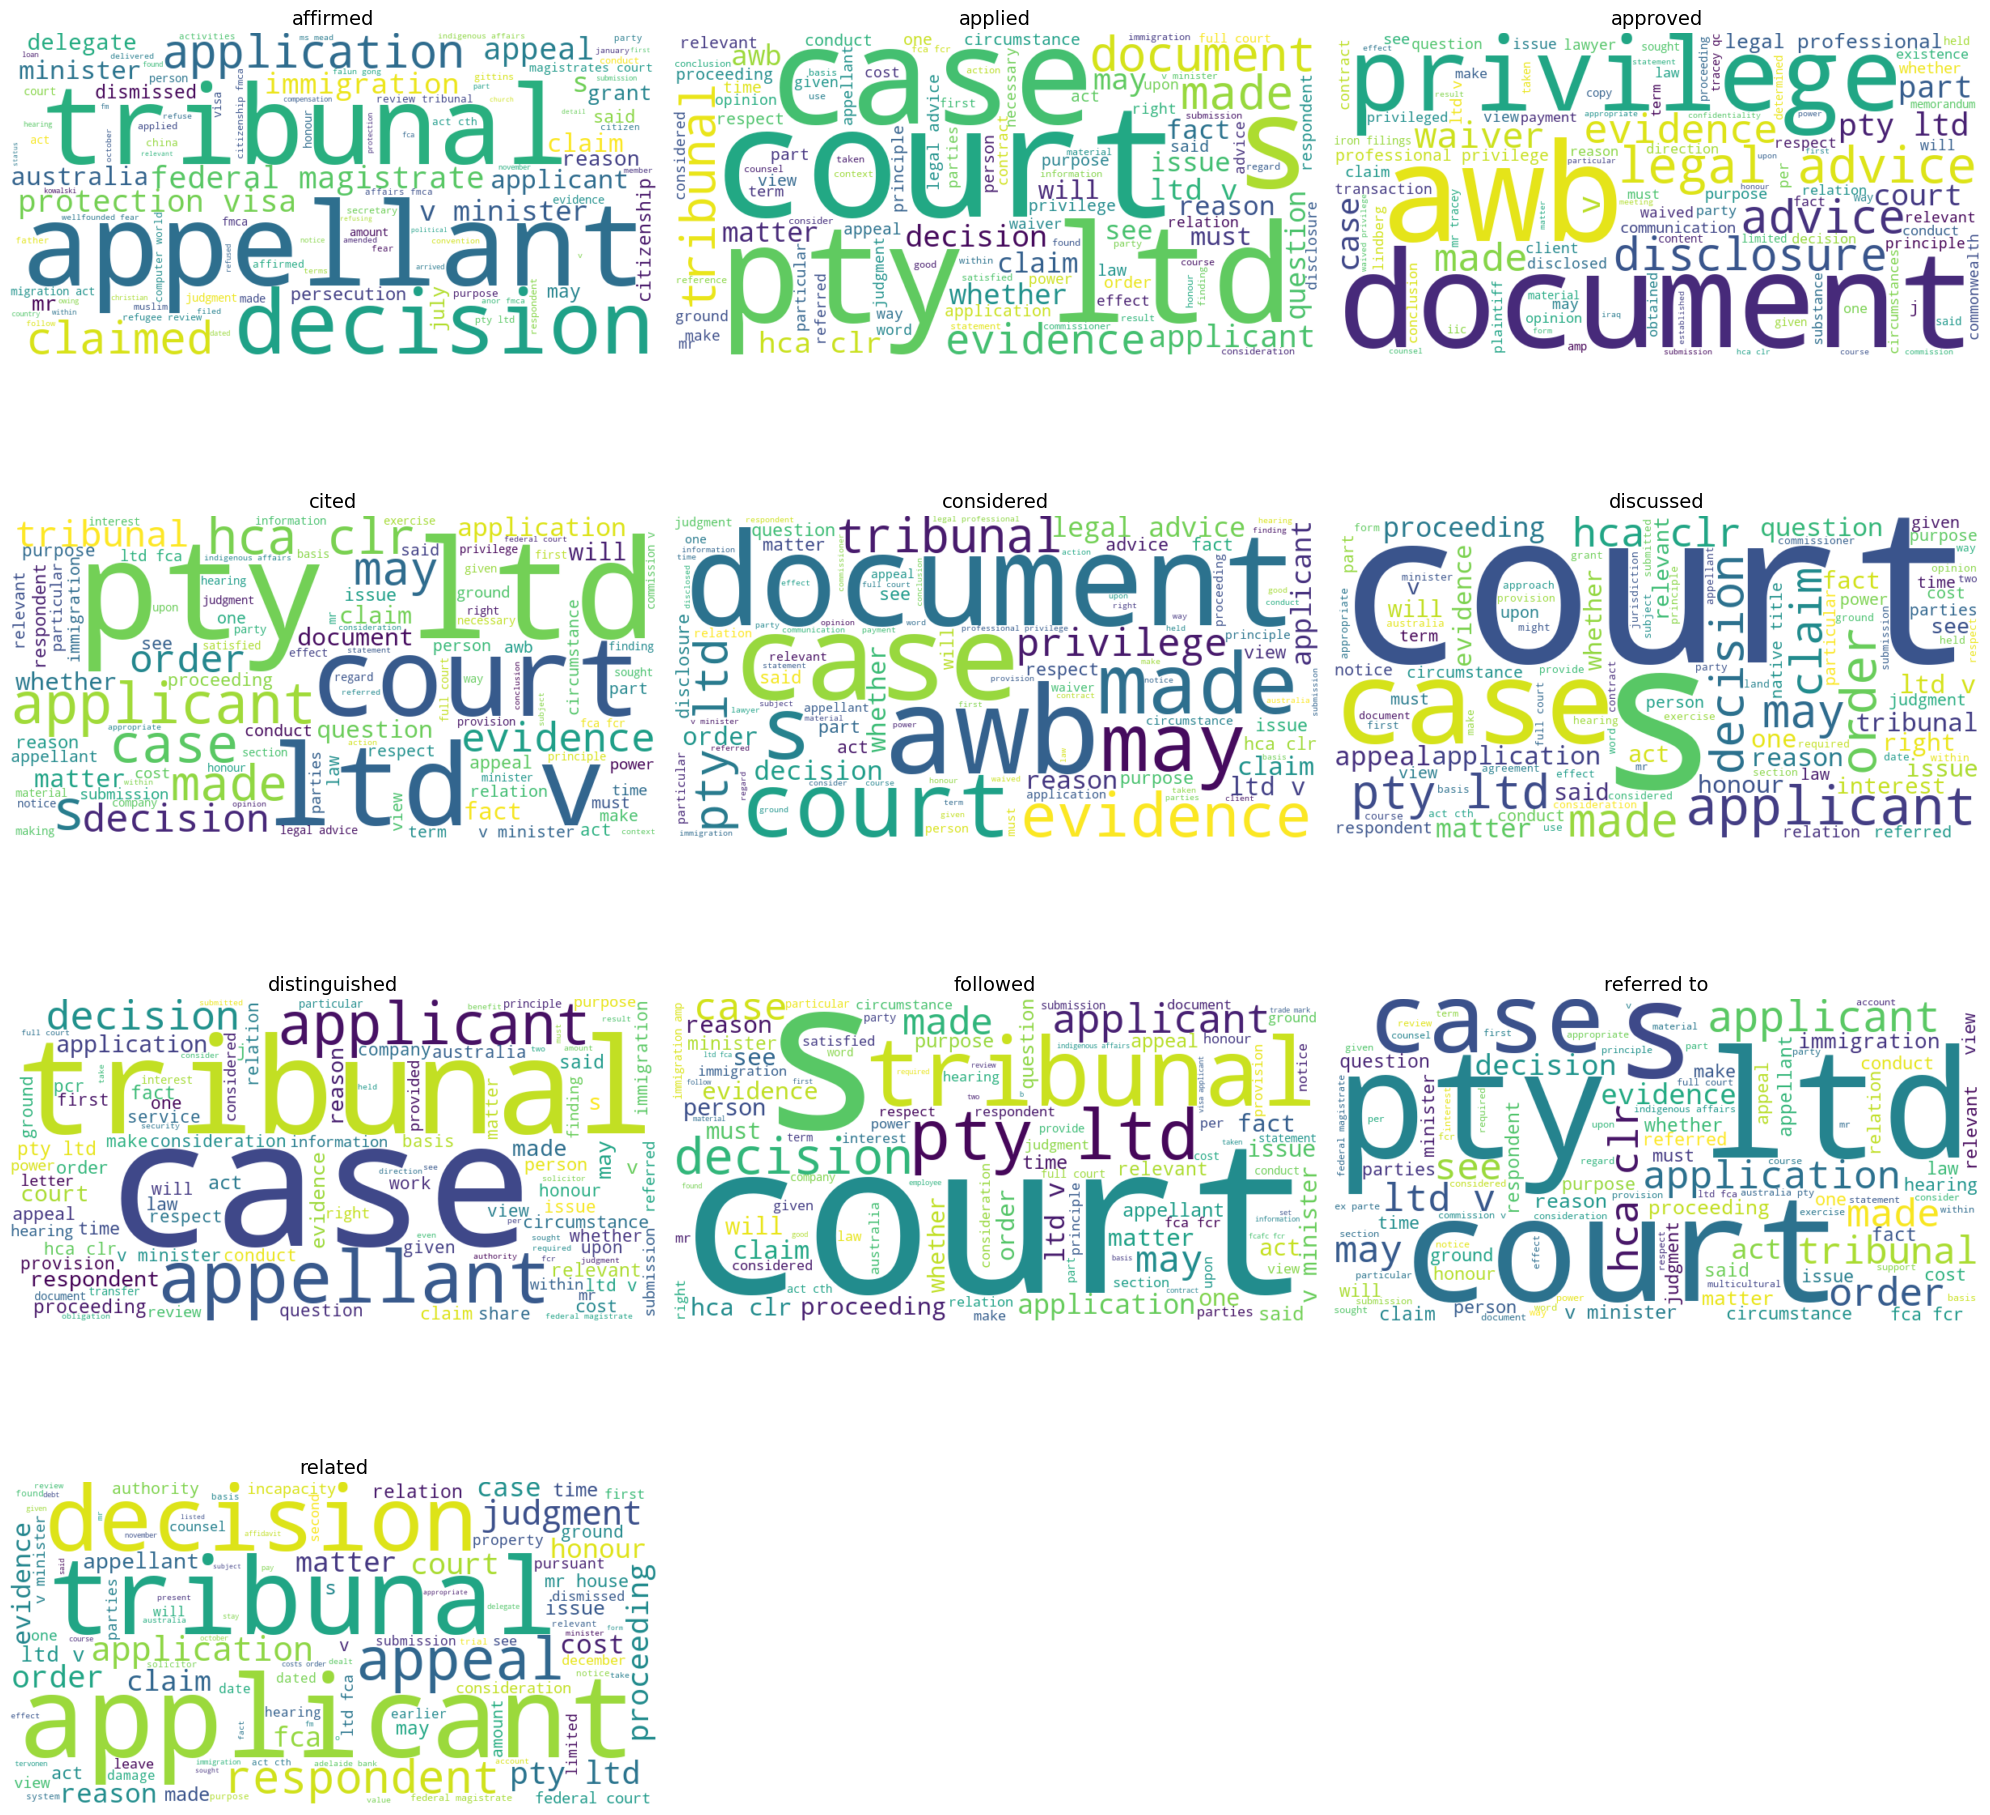

In [40]:
# тексты по классам

class_texts = df_clean.groupby("case_outcome")["clean_text"].apply(lambda x: " ".join(x))

plt.figure(figsize=(20, 20))
for i, (label, text) in enumerate(class_texts.items()):
    plt.subplot(4, 3, i + 1)  
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=100,
        colormap='viridis'
    ).generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(label, fontsize=14)

plt.tight_layout()
plt.show()